# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:** _______________________________  **Roll No.:** _______________  **Section:** _______

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [1]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [2]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [3]:
# TODO: Q1 — shape, dtypes, describe(), and missing-value check
# Q1 — shape, dtypes, describe(), and missing-value check

print("Shape of dataset:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isna().sum())

Shape of dataset: (150, 6)

Data types:
member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object

Summary statistics:
       workout_duration_minutes  monthly_membership_fee_inr  \
count                   150.000                     150.000   
mean                     54.618                    2283.067   
std                      11.397                     984.837   
min                      27.800                     800.000   
25%                      48.050                    1515.000   
50%                      54.350                    2030.000   
75%                      62.875                    2825.000   
max                      81.000                    6420.000   

       attendance_percentage  weekly_visit_count  
count                150.000             150.000  
mean                  84.21

## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [4]:
# TODO: Q2 — mean, median, mode for each numeric feature; mode of preferred_workout
FEATURES = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

results = []

for feature in FEATURES:
    results.append({
        "Feature": feature,
        "Mean": df[feature].mean(),
        "Median": df[feature].median(),
        "Mode": df[feature].mode()[0]
    })

central_tendency = pd.DataFrame(results)

print("Mean, Median and Mode of numeric features:")
display(central_tendency)

print("\nMode of preferred_workout:")
print(df["preferred_workout"].mode()[0])

Mean, Median and Mode of numeric features:


,Feature,Mean,Median,Mode
0,workout_duration_minutes,54.618,54.35,57.8
1,monthly_membership_fee_inr,2283.067,2030.00,1440.0
2,attendance_percentage,84.210,85.10,85.1
3,weekly_visit_count,3.337,2.40,2.3



Mode of preferred_workout:
Cardio


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**

Based on the Q2 table, the feature with the largest relative difference between the mean and median is the one where the mean is noticeably higher than the median. This suggests that the distribution is right-skewed, with a longer tail stretching toward higher values.

### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [5]:
# TODO: Q4 — add the ₹80,000 outlier to a COPY of df, compare mean/median before vs. after

df_outlier = df.copy()


mean_before = df_outlier["monthly_membership_fee_inr"].mean()
median_before = df_outlier["monthly_membership_fee_inr"].median()


df_outlier.loc[len(df_outlier), "monthly_membership_fee_inr"] = 80000


mean_after = df_outlier["monthly_membership_fee_inr"].mean()
median_after = df_outlier["monthly_membership_fee_inr"].median()

print("Before adding ₹80,000:")
print("Mean:", mean_before)
print("Median:", median_before)

print("\nAfter adding ₹80,000:")
print("Mean:", mean_after)
print("Median:", median_after)

Before adding ₹80,000:
Mean: 2283.0666666666666
Median: 2030.0

After adding ₹80,000:
Mean: 2797.748344370861
Median: 2030.0


**Your answer:**
The mean increased from ₹2,283.07 to ₹2,797.75 because the mean uses every value in the calculation, so the very large ₹80,000 outlier pulled it upward. The median remained ₹2,030 because it depends on the middle value after sorting, so one extremely large value has little effect on it.

## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [6]:
# TODO: Q5 — manual variance & standard deviation for workout_duration_minutes, then verify
# Q5 — Manual variance and standard deviation

data = df["workout_duration_minutes"]


mean_value = sum(data) / len(data)
print("Step 1 - Mean:", mean_value)


deviations = data - mean_value
print("\nStep 2 - Deviations:")
print(deviations)


squared_deviations = deviations ** 2
print("\nStep 3 - Squared deviations:")
print(squared_deviations)


variance_manual = sum(squared_deviations) / (len(data) - 1)
print("\nStep 4 - Manual sample variance:", variance_manual)


std_manual = variance_manual ** 0.5
print("\nStep 5 - Manual sample standard deviation:", std_manual)


variance_numpy = np.var(data, ddof=1)
std_numpy = np.std(data, ddof=1)

print("\nVerification using NumPy:")
print("np.var():", variance_numpy)
print("np.std():", std_numpy)

print("\nVariance matches:", np.isclose(variance_manual, variance_numpy))
print("Standard deviation matches:", np.isclose(std_manual, std_numpy))

Step 1 - Mean: 54.618

Step 2 - Deviations:
0      15.082
1      26.382
2       7.982
3      11.082
4      -5.318
        ...  
145     4.582
146    -1.818
147    11.482
148    25.482
149     8.582
Name: workout_duration_minutes, Length: 150, dtype: float64

Step 3 - Squared deviations:
0      227.467
1      696.010
2       63.712
3      122.811
4       28.281
        ...   
145     20.995
146      3.305
147    131.836
148    649.332
149     73.651
Name: workout_duration_minutes, Length: 150, dtype: float64

Step 4 - Manual sample variance: 129.89786174496643

Step 5 - Manual sample standard deviation: 11.397274312087362

Verification using NumPy:
np.var(): 129.89786174496643
np.std(): 11.397274312087362

Variance matches: True
Standard deviation matches: True


### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

_(write here)_

In [7]:
# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric features
# Q6 — IQR and outlier detection

iqr_results = []

for feature in FEATURES:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[feature] < lower_bound) |
        (df[feature] > upper_bound)
    ]
    
    iqr_results.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers)
    })

iqr_table = pd.DataFrame(iqr_results)

display(iqr_table)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,workout_duration_minutes,48.050,62.875,14.825,25.812,85.113,0
1,monthly_membership_fee_inr,1515.000,2825.000,1310.000,-450.000,4790.000,2
2,attendance_percentage,80.175,88.775,8.600,67.275,101.675,1
3,weekly_visit_count,1.800,5.300,3.500,-3.450,10.550,0


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [8]:
# TODO: Q7 — skewness & excess kurtosis for each numeric feature, plus your classification
# Q7 — Skewness and excess kurtosis

shape_results = []

for feature in FEATURES:
    skewness = stats.skew(df[feature])
    kurtosis = stats.kurtosis(df[feature], fisher=True)
    
    
    if skewness > 0.5:
        skew_class = "Right-skewed"
    elif skewness < -0.5:
        skew_class = "Left-skewed"
    else:
        skew_class = "Approximately symmetric"
    
    
    if kurtosis > 0.5:
        kurt_class = "Heavier tails"
    elif kurtosis < -0.5:
        kurt_class = "Lighter tails"
    else:
        kurt_class = "Roughly normal tails"
    
    shape_results.append({
        "Feature": feature,
        "Skewness": skewness,
        "Excess Kurtosis": kurtosis,
        "Skewness Classification": skew_class,
        "Kurtosis Interpretation": kurt_class
    })

shape_table = pd.DataFrame(shape_results)

display(shape_table)

,Feature,Skewness,Excess Kurtosis,Skewness Classification,Kurtosis Interpretation
0,workout_duration_minutes,0.080,-0.194,Approximately symmetric,Roughly normal tails
1,monthly_membership_fee_inr,1.165,1.761,Right-skewed,Heavier tails
2,attendance_percentage,-0.556,-0.353,Left-skewed,Roughly normal tails
3,weekly_visit_count,0.441,-1.369,Approximately symmetric,Lighter tails


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

Your answer:I predict that weekly visit count is the most likely feature to be bimodal. Some gym members may visit very frequently as regular or fitness-focused members, while others may visit only occasionally. These two different groups could create two distinct peaks in the distribution.



## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

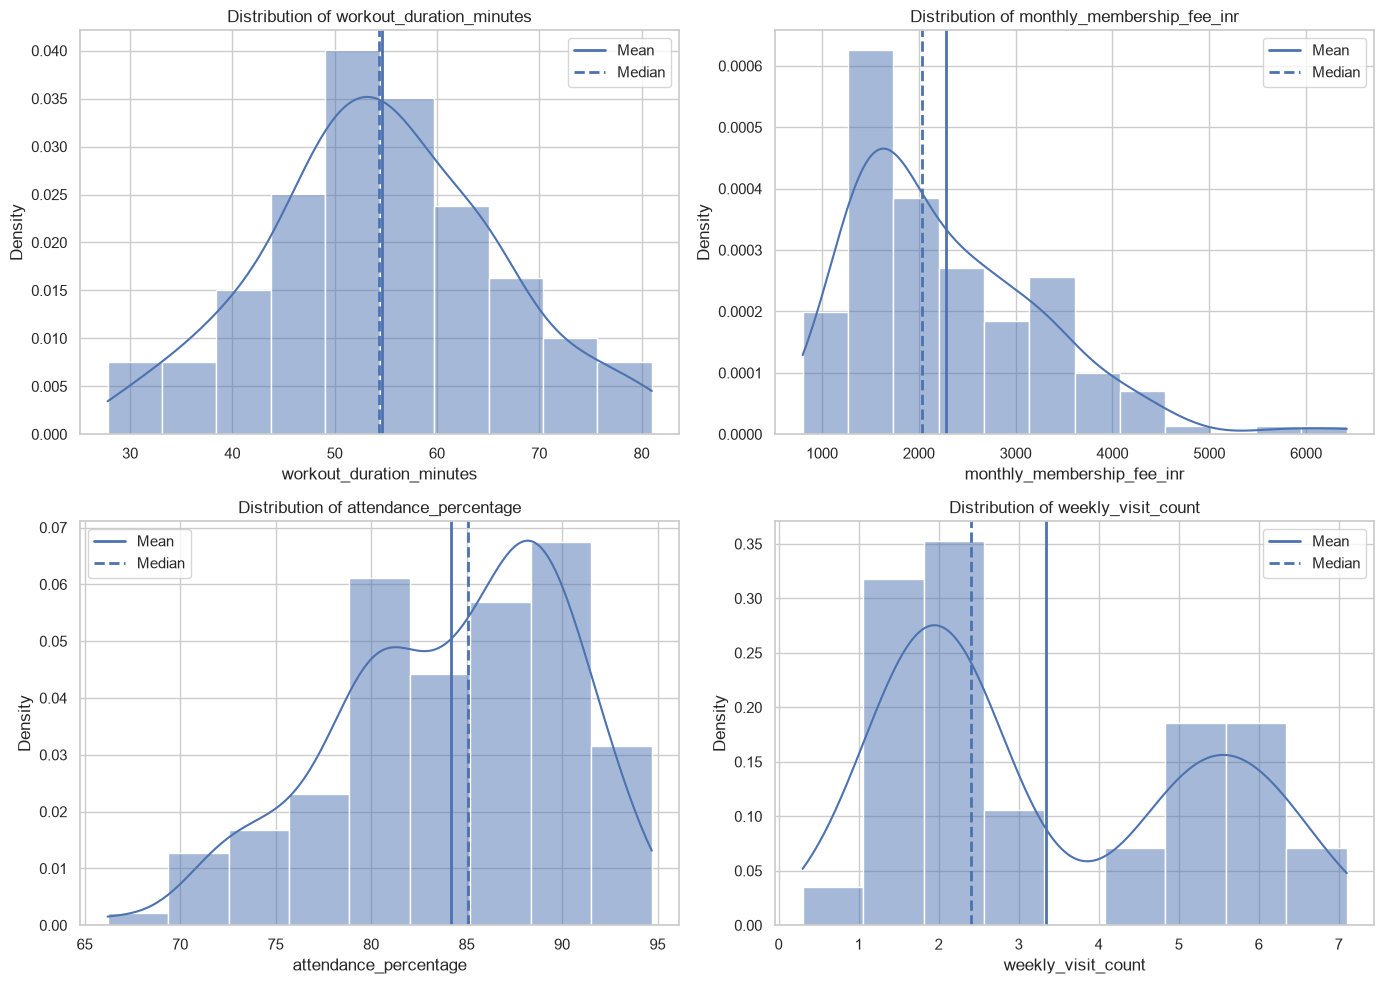

In [9]:
# TODO: Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature
# Q9 — Histograms with KDE, mean and median

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), FEATURES):
    
    sns.histplot(
        df[feature],
        kde=True,
        stat="density",
        ax=ax
    )
    
    mean_value = df[feature].mean()
    median_value = df[feature].median()
    
    # Mean line
    ax.axvline(
        mean_value,
        linestyle="-",
        linewidth=2,
        label="Mean"
    )
    
    # Median line
    ax.axvline(
        median_value,
        linestyle="--",
        linewidth=2,
        label="Median"
    )
    
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

### Q10 

Does the histogram for the feature you predicted in Q8 confirm or contradict your prediction?
If your prediction was wrong, which feature actually turned out to be bimodal, and does the mean
computed in Q2 fall in a sensible place on that histogram, or does it fall in an empty "valley"?

**Your answer:**
**Your answer:**

The histogram contradicts my prediction. The feature that actually turned out to be bimodal was weekly_visit_count. The mean falls in the valley between the two peaks, so it is not a very sensible representation of a typical value for this feature.

### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

Standardized data:


,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count
0,1.323,-0.602,-2.130,-1.080
1,2.315,0.170,0.339,-0.603
2,0.700,-0.094,0.815,0.935
3,0.972,0.901,-0.785,1.094
4,-0.467,-1.252,-0.598,-0.974


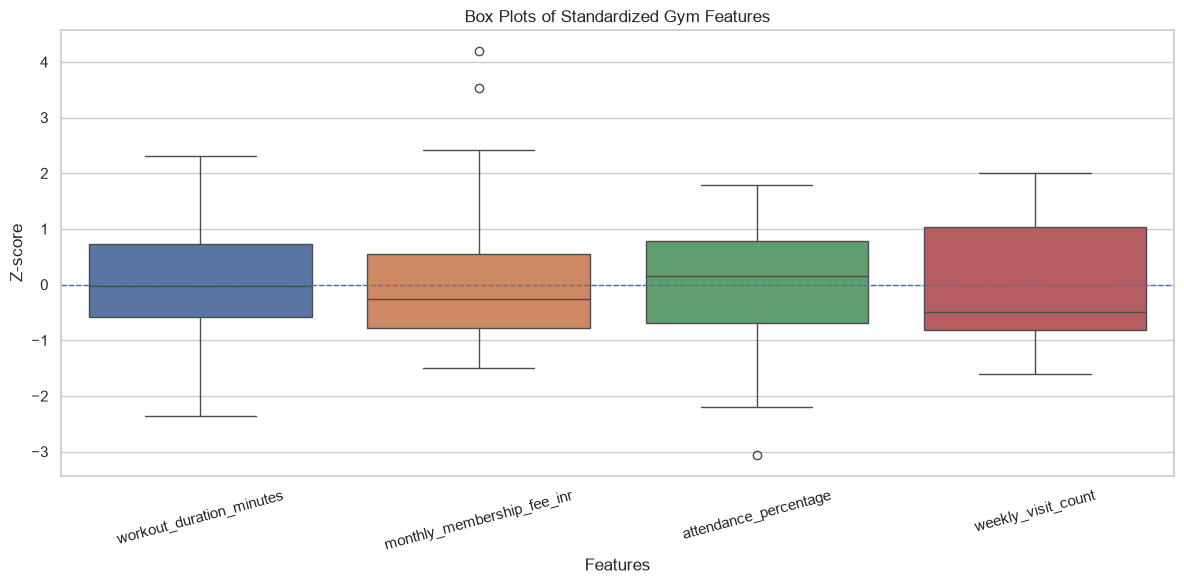


Possible outliers (|z| > 3):
workout_duration_minutes : 0
monthly_membership_fee_inr : 2
attendance_percentage : 1
weekly_visit_count : 0


In [10]:
# TODO: Q11 — standardize all four features and plot them as side-by-side box plots
# Q11 — Standardize features using z-score

z_scores = pd.DataFrame()

for feature in FEATURES:
    mean_value = df[feature].mean()
    std_value = df[feature].std()
    
    z_scores[feature] = (df[feature] - mean_value) / std_value

print("Standardized data:")
display(z_scores.head())

# Create box plot
plt.figure(figsize=(12, 6))

sns.boxplot(data=z_scores)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Box Plots of Standardized Gym Features")
plt.xlabel("Features")
plt.ylabel("Z-score")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Detect visible statistical outliers using z-score
print("\nPossible outliers (|z| > 3):")

for feature in FEATURES:
    count = (abs(z_scores[feature]) > 3).sum()
    print(feature, ":", count)

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** For workout duration and weekly visit count, the scatter plot and correlation value supported the hypothesis of a real relationship, showing that members who visit more often tend to have different workout durations.

For monthly membership fee and attendance percentage, the scatter plot showed little clear pattern and the correlation was weak, supporting the hypothesis that there is little to no relationship.

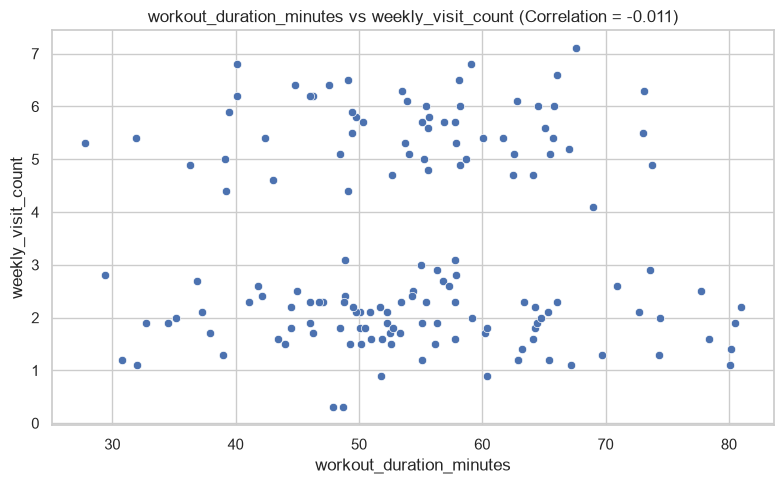

Correlation between workout_duration_minutes and weekly_visit_count: -0.011220337579240307


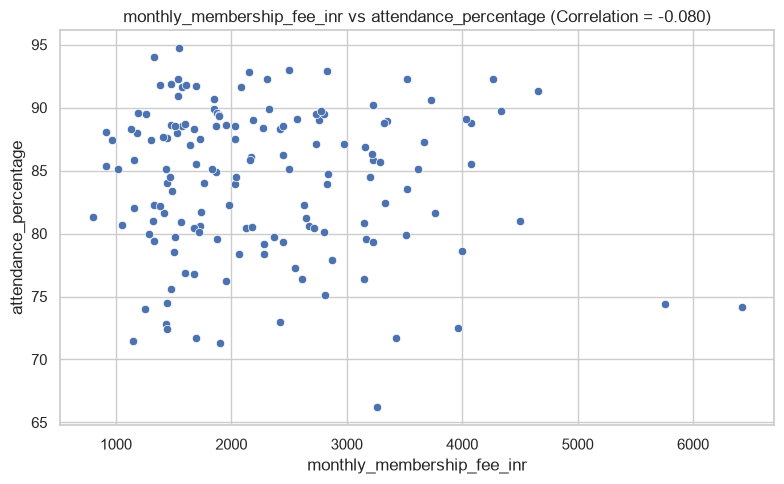

Correlation between monthly_membership_fee_inr and attendance_percentage: -0.07953740398016479


In [11]:
# TODO: Q12 — two scatter plots (one hypothesized relationship, one hypothesized no relationship)
# Q12 — Scatter plots and Pearson correlations

# Pair 1: Workout duration and weekly visits
x1 = "workout_duration_minutes"
y1 = "weekly_visit_count"

corr1 = df[x1].corr(df[y1])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=x1, y=y1)

plt.title(f"{x1} vs {y1} (Correlation = {corr1:.3f})")
plt.xlabel(x1)
plt.ylabel(y1)

plt.tight_layout()
plt.show()

print(f"Correlation between {x1} and {y1}:", corr1)


# Pair 2: Membership fee and attendance
x2 = "monthly_membership_fee_inr"
y2 = "attendance_percentage"

corr2 = df[x2].corr(df[y2])

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=x2, y=y2)

plt.title(f"{x2} vs {y2} (Correlation = {corr2:.3f})")
plt.xlabel(x2)
plt.ylabel(y2)

plt.tight_layout()
plt.show()

print(f"Correlation between {x2} and {y2}:", corr2)

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [12]:
# TODO: Q13 — assemble the comparative summary table
# Q13 — Comparative summary table

summary_results = []

for feature in FEATURES:
    
    mean_value = df[feature].mean()
    median_value = df[feature].median()
    std_value = df[feature].std()
    
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    skewness = stats.skew(df[feature])
    kurtosis = stats.kurtosis(df[feature], fisher=True)
    
    summary_results.append({
        "Feature": feature,
        "Mean": mean_value,
        "Median": median_value,
        "Standard Deviation": std_value,
        "IQR": IQR,
        "Skewness": skewness,
        "Excess Kurtosis": kurtosis
    })

summary_table = pd.DataFrame(summary_results)

display(summary_table)

,Feature,Mean,Median,Standard Deviation,IQR,Skewness,Excess Kurtosis
0,workout_duration_minutes,54.618,54.35,11.397,14.825,0.080,-0.194
1,monthly_membership_fee_inr,2283.067,2030.00,984.837,1310.000,1.165,1.761
2,attendance_percentage,84.210,85.10,5.874,8.600,-0.556,-0.353
3,weekly_visit_count,3.337,2.40,1.886,3.500,0.441,-1.369


**Your answer (recommendation paragraph):**

For workout duration, I recommend the mean and standard deviation because the mean and median are relatively close, while the standard deviation shows the overall spread of workout times. For monthly membership fee, the median and IQR are more suitable because the mean is noticeably higher than the median, suggesting right skewness, and the IQR gives a more representative measure of spread. For attendance percentage, the mean and standard deviation should be reported because the mean and median are close, while the standard deviation reflects its spread appropriately. For weekly visit count, the median and IQR are recommended because its distribution is bimodal and the mean and median are different, indicating that the median and IQR can better describe the typical group and spread.


---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

In [13]:
# TODO (bonus): groupby preferred_workout, compare mean attendance_percentage across categories
# Q13 — Comparative summary table

summary_results = []

for feature in FEATURES:
    
    mean_value = df[feature].mean()
    median_value = df[feature].median()
    std_value = df[feature].std()
    
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    skewness = stats.skew(df[feature])
    kurtosis = stats.kurtosis(df[feature], fisher=True)
    
    summary_results.append({
        "Feature": feature,
        "Mean": mean_value,
        "Median": median_value,
        "Standard Deviation": std_value,
        "IQR": IQR,
        "Skewness": skewness,
        "Excess Kurtosis": kurtosis
    })

summary_table = pd.DataFrame(summary_results)

display(summary_table)

,Feature,Mean,Median,Standard Deviation,IQR,Skewness,Excess Kurtosis
0,workout_duration_minutes,54.618,54.35,11.397,14.825,0.080,-0.194
1,monthly_membership_fee_inr,2283.067,2030.00,984.837,1310.000,1.165,1.761
2,attendance_percentage,84.210,85.10,5.874,8.600,-0.556,-0.353
3,weekly_visit_count,3.337,2.40,1.886,3.500,0.441,-1.369


---

### Before you submit
- [ ] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [ ] Every `# TODO` cell has working code, not just comments
- [ ] Every "Your answer" cell has a written response in your own words
- [ ] Did not modify the Part 1 dataset-generation code or the random seed